# Notebook for preprocessing EDGAR8 for use as anthropogenic prior

* select years
* cut domain
* sum sector-specific gridded fluxes together 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

In [2]:
DATA_PATH1 = "/home/pietaril/Documents/data/EDGAR8_CO2/bio_EDGAR/"
DATA_PATH2 = "/home/pietaril/Documents/data/EDGAR8_CO2/IEA_EDGAR/"
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/summed_sectors/"

def hours_in_months(year):
    """
    Calculate the number of hours in each month of a given year,
    taking into account leap years.

    Args:
        year (int): The year to calculate the hours for.

    Returns:
        an array with hours in each month of the year
    """
    import calendar

 
    # Get the number of days in each month of the year. Note that monthrange counts months from 1 to 12, 
    # and takes leap years into account.
    days_in_month = [calendar.monthrange(year, month)[1] for month in range(1, 13)]

    # Calculate hours for each month
    hours_per_month = [days_in_month[i] * 24 for i in range(12)]

    return np.array(hours_per_month)

def get_filenames(dirpaths):
    """Helper function to list paths to all EDGAR files on my laptop"""
    filenames = []
    for dirpath in dirpaths:
        for subdir in os.listdir(dirpath):
            subdirpath = os.path.join(dirpath, subdir)
            filenames +=  [os.path.join(subdirpath,f) for f in os.listdir(subdirpath) if f.endswith(".nc")]
    return filenames


def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[-1])
    return year

def select_area(aoi, ds):
    """Helper function to select the area of interest from a dataset."""
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset





def sum_sectors(aoi, input_files, output_file):
    """
    Sums the fluxes from multiple NetCDF files corresponding to the different sectors
    of EDGAR, converts them from kg/m2/s to kg/m2/hr and writes the result to a new NetCDF file.

    Parameters:
    - input_files (list of str): List of paths to raw EDGAR8 flux files.
    - output_file (str): Path to the output NetCDF file.
    """
 

    # Open all input files
    datasets = [xr.open_dataset(file) for file in input_files]
    

    #pick area
    subsets = [select_area(aoi, ds) for ds in datasets]

    #convert to double precision

    subsets64 = [ds.assign({"fluxes": ds["fluxes"].astype('float64')}) 
                 for ds in subsets
]


    # Compute the sum of fluxes across all datasets

    flux_sum = sum(ds for ds in subsets64)

    #convert from kg/m2/s to kg/m2/hr
    flux_sum["fluxes"] = flux_sum["fluxes"]*60*60

    #rename variables to match CIF standard
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        "fluxes": "emi_anth"
    }
    flux_sum = flux_sum.rename(rename_map)
    

    # Save the result to a new NetCDF file
    
    flux_sum.attrs.update({"description": "Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes from all sectors",
                            "units": "kg m-2 hr-1"})



    # Write the output dataset to a new NetCDF file
    flux_sum.to_netcdf(output_file, encoding={'time':{'units': "days since 1900-01-01"}})

    # Close all datasets
    for ds in datasets:
        ds.close()

    print(f"Sum of fluxes saved to file {output_file}")
    
    






# Examine the structure of the original EDGAR 2024 datasets

In [62]:
fnames = get_filenames([DATA_PATH1, DATA_PATH2])
ds = xr.open_dataset(fnames[0], )
ds

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2015-01-15 2015-02-15 ... 2015-12-15
Data variables:
    fluxes   (time, lat, lon) float32 ...
Attributes:
    description:       Industrial processes
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

# Sum the gridded fluxes of different sectors together and save

In [19]:



aoi = [-15, 40, 34, 73]
OUT_PATH = f"/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/summed_sectors/"

fnames = get_filenames([DATA_PATH1, DATA_PATH2])


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)

for year in range(2008,2024):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==16
    output_file = f"{OUT_PATH}EDGAR8_CO2_monthly_flux_summed_sectors_{year}.nc"
    ds = sum_sectors(aoi, files_1year, output_file)
    


Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2008.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2009.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2010.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2011.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2012.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2013.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors/EDGAR8_CO2_monthly_flux_summed_sectors_2014.nc
Sum of fluxes saved to file /home/pietaril/Documents/data/EDGAR8_CO2/summed_sectors

# Check the created files

In [125]:
sum_files = os.listdir(OUT_PATH)
print(sum_files)
sum_sectors = xr.open_dataset(OUT_PATH+sum_files[5])
sum_sectors

['EDGAR8_CO2_monthly_flux_summed_sectors_2016.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2017.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2015.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2009.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2021.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2020.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2012.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2022.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2014.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2011.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2023.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2013.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2008.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2019.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2018.nc', 'EDGAR8_CO2_monthly_flux_summed_sectors_2010.nc']


<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 12)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2020-01-15 2020-02-15 ... 2020-12-15
Data variables:
    emi_anth   (time, latitude, longitude) float64 ...
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 monthly fluxes from all s...
    units:        kg m-2 hr-1

In [ ]:
#rename files
# fnames = os.listdir(OUT_PATH)
# for fname in fnames:
#     year = extract_year(fname)
#     newname = f"EDGAR8_CO2_monthly_flux_summed_sectors_{year}.nc"
#     os.rename(os.path.join(OUT_PATH, fname), os.path.join(OUT_PATH, newname))

In [ ]:
import netCDF4 as nc
print(sum_files[0])
data_nc = nc.Dataset(OUT_PATH+sum_files[0], 'r')
data_nc.variables

# Rename variables in the already processed files

In [10]:
def rename_variables_in_netcdf(input_dir, output_dir, rename_map):
    """
    Reads NetCDF files from a directory, renames specified variables, and writes the changes to new files.

    Parameters:
        input_dir (str): Directory containing input NetCDF files.
        output_dir (str): Directory to save the modified NetCDF files.
        rename_map (dict): Mapping of old variable names to new variable names (e.g., {'old_var': 'new_var'}).
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for filename in os.listdir(input_dir):
        if filename.endswith(".nc"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            try:
                # Open the NetCDF file
                ds = xr.open_dataset(input_path)

                # Rename variables
                ds = ds.rename(rename_map)

                # Write the modified dataset to a new file
                ds.to_netcdf(output_path)

                print(f"Processed file: {filename}")

            except Exception as e:
                print(f"Error processing file {filename}: {e}")

# Define input directory, output directory, and rename mapping
input_directory =  "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums_old/"
output_directory = "/home/pietaril/Documents/data/EDGAR8_CO2/gridded_monthly_flux_sums/"
variable_rename_map = {
    "lat": "latitude",
    "lon": "longitude"
}

rename_variables_in_netcdf(input_directory, output_directory, variable_rename_map)




Processed file: EDGAR8_CO2_monthly_flux_sums_2017.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2016.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2021.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2011.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2010.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2019.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2015.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2009.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2020.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2022.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2012.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2014.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2018.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2008.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2013.nc
Processed file: EDGAR8_CO2_monthly_flux_sums_2023.nc


# Plot the preprocessed fluxes

In [126]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


def plot_fluxmaps(sum_sectors, figpath=None):
    data = sum_sectors["emi_anth"]
    g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
                     subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "anth CO$_2$ prior flux [$kg$ $m^{-2} hr^{-1}$]", shrink=0.9 ),

    )


    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()

    if not figpath==None:
        figname = f"EDGAR8_summed_monthly_CO2_fluxmaps_{time[0:4]}.png"
        plt.savefig(figpath+figname)
        plt.draw()
    



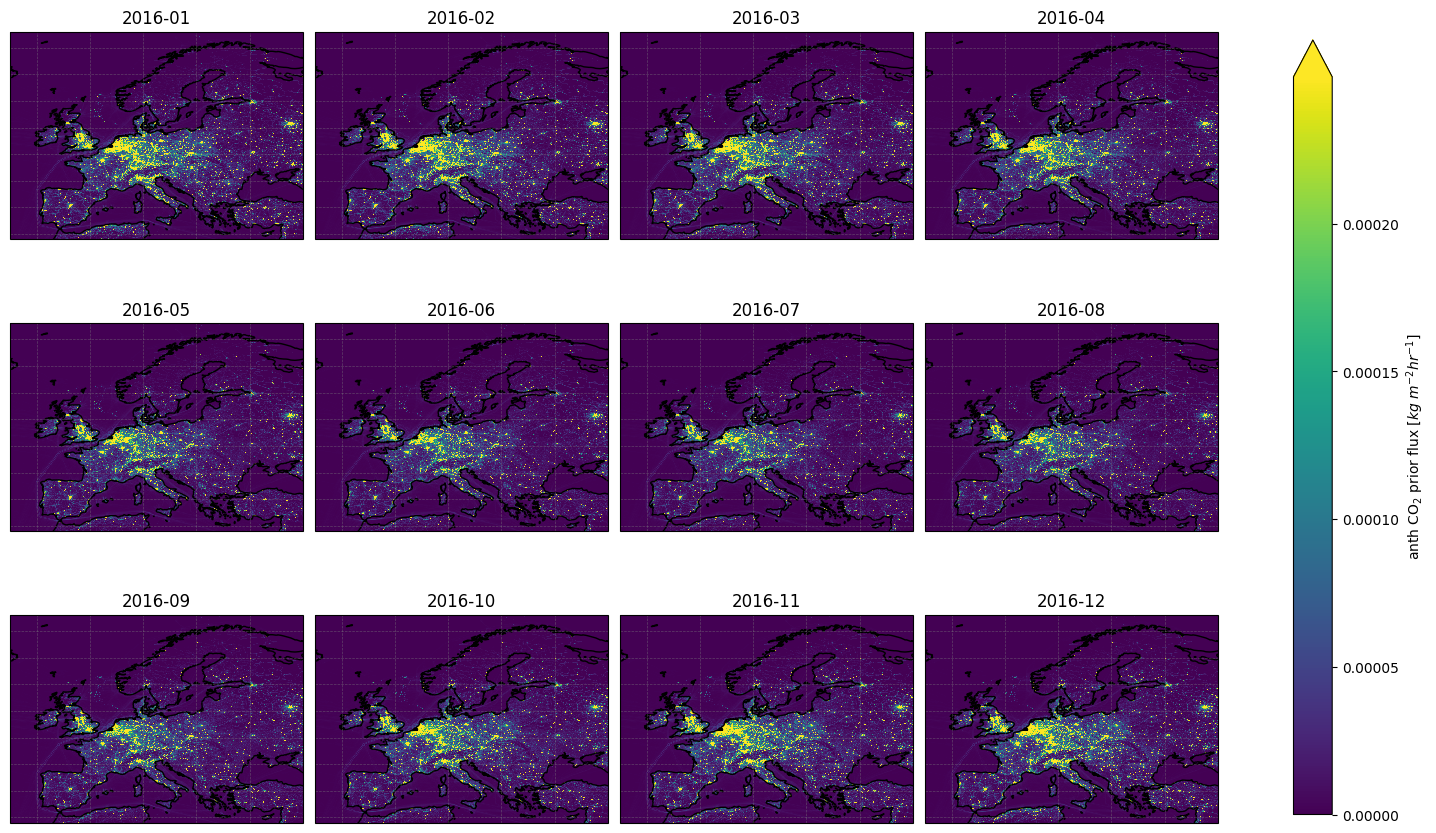

In [127]:

sum_files = os.listdir(OUT_PATH)
for file in sum_files[:1]:
    sum_sectors = xr.open_dataset(OUT_PATH+file)
    plot_fluxmaps(sum_sectors)
    #plot_fluxmaps(sum_sectors, "/home/pietaril/Documents/plots/EDGAR8/summed_gridmaps/")
    sum_sectors.close()


# Conversion to g m-2 yr-1 for Tuulas plots

In [3]:
def monthly_res_fluxes_to_g_per_m2_per_yr(ds):
    #ensure that time axis in ascending order
    ds = ds.sortby("time")
    #pick the first time stamp to be the time coordinate representing the whole year
    time = ds["time"].values[0]
    # convert kg/m2/hr to g/m2/hr
    out = ds["emi_anth"]*1000
    
    #compute how many hours in each month of the year
    year = ds["time"].dt.year.values[0]
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))

    #multiply the monthly gridmaps by hours per month to get unit g/m2/month_i for each month
    out = hours_per_month *out

    #sum the monthly gridmaps to get one map with unit g/m2/yr
    out = out.sum(dim="time")

    out = out.to_dataset()

    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out

In [100]:
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/summed_sectors/"
fnames = [os.path.join(OUT_PATH, f) for f in os.listdir(OUT_PATH)]
datasets = [xr.open_dataset(fname) for fname in fnames]

yearly_fluxes = []
for ds in datasets:
    yearly_flux = monthly_res_fluxes_to_g_per_m2_per_yr(ds)
    yearly_fluxes.append(yearly_flux)

ds_allyears = xr.concat(yearly_fluxes, dim="time") 
ds_allyears = ds_allyears.sortby("time")
ds_allyears

<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 16)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2008-01-15 2009-01-15 ... 2023-01-15
Data variables:
    emi_anth   (time, latitude, longitude) float64 6.757 6.439 ... 1.463 0.634

In [101]:
from truncate_colormap import truncate_colormap
import matplotlib as mpl

#select Scandinavia


aoi_scand = [2, 31.5, 54, 72]

scand = select_area(aoi_scand, ds_allyears)

cbar_label = "emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "emi_anth"
ncols = 4
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="Anthropogenic yearly CO$_2$ emissions"




In [131]:


def plot_yearly_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.8

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:4]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

    # Draw the plot
    plt.draw()

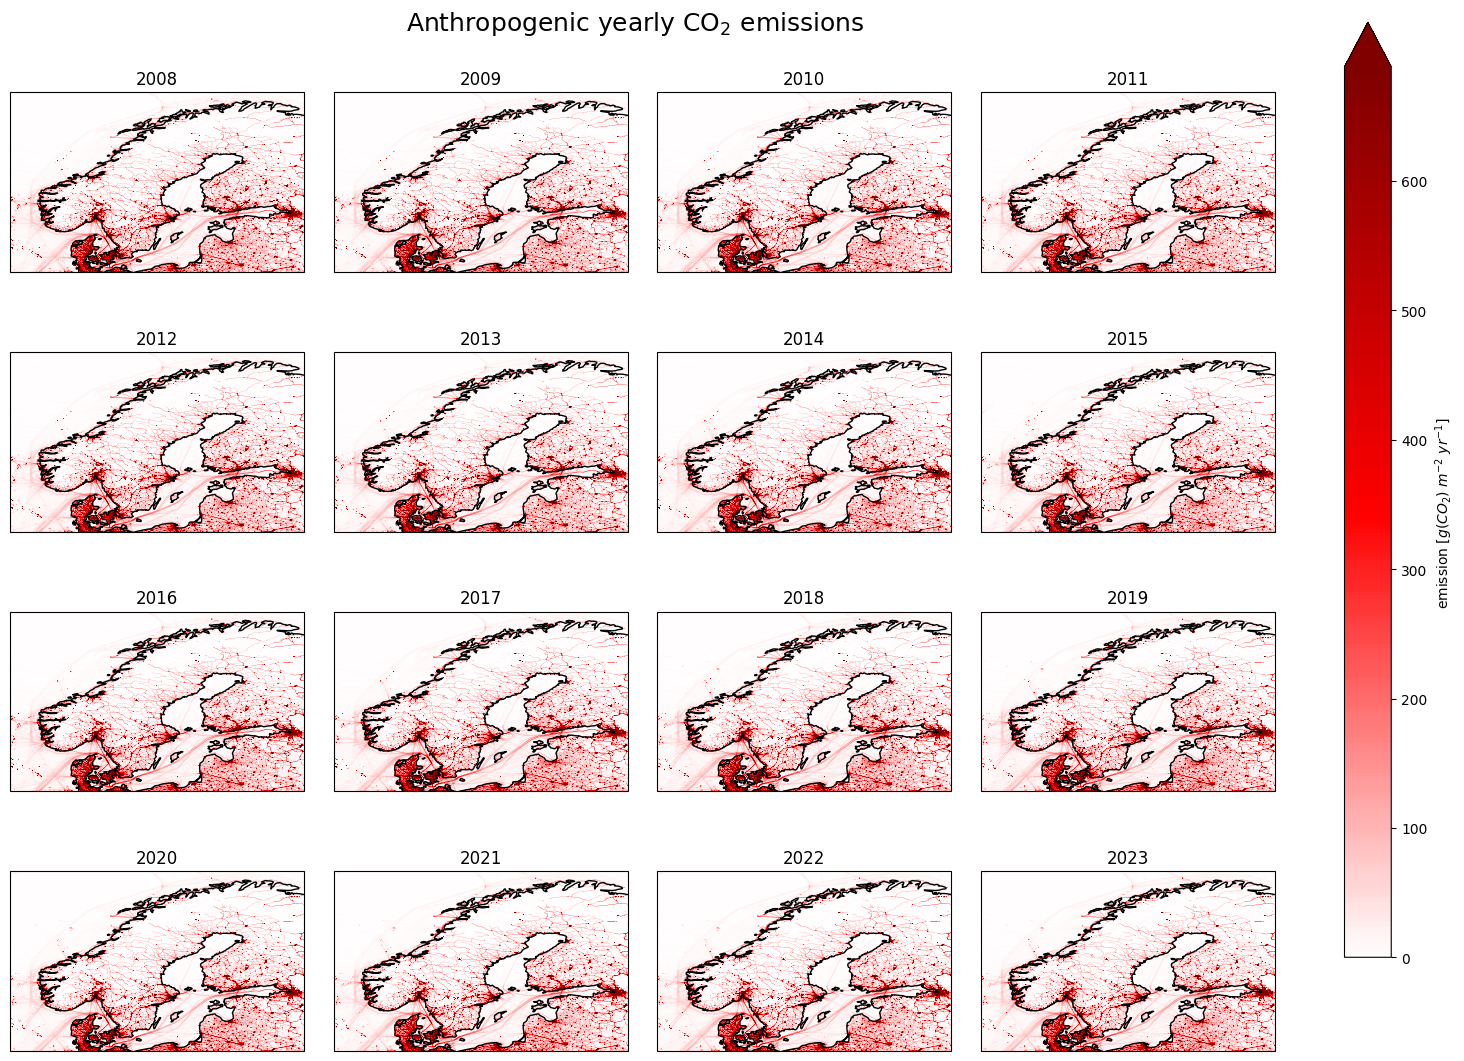

In [132]:
plot_yearly_fluxes(scand, "emi_anth", ncols, cmap, cbar_label, suptitle)

# Plot the average yearly flux for a range of years

In [102]:
#compute the mean for the chosen range of years
years = range(2018, 2023)

scand_18_22 = scand.isel(time=scand.time.dt.year.isin(years))
scand_ave_all_sectors = scand.mean(dim="time")


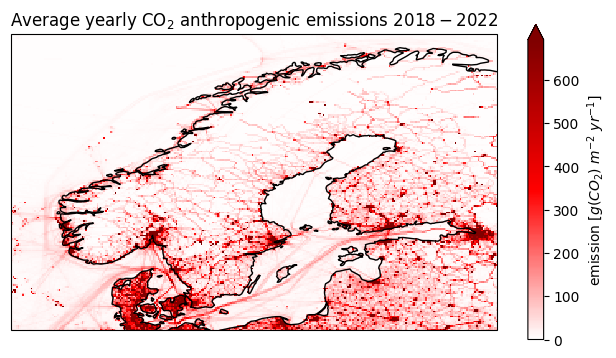

In [103]:
cbar_label = "emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "emi_anth"
cbar_shrink = 0.7
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="Average yearly CO$_2$ anthropogenic emissions $2018-2022$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

scand_ave_all_sectors["emi_anth"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/"
figname = f"EDGAR8_scandinavia_mean_emis_2018_2022.png"
#plt.savefig(figpath+figname)
plt.draw()

# Compute fluxes (kg/m2/hr) for each sector separately
* biogenic and iea summed together per sector

In [104]:

def sectorwise_fluxes(sector, sector_fnames, aoi, output_file):
    """Compute fluxes for an EDGAR sector
    
    Inputs:
    - sector (str): name of the sector in caps
    - sector_fnames (list of str): paths to the files corresponding to the fluxes of the sector (both IEA and biogenic)
    - aoi (list) : edge coordinates of the area of interest
    - output_file (str): path to the output file
    
    
    """

   
    # Open all input files 
    datasets = [xr.open_dataset(file) for file in sector_fnames]


    #pick area
    subsets = [select_area(aoi, ds) for ds in datasets]

    #convert to double precision

    subsets64 = [ds.assign({"fluxes": ds["fluxes"].astype('float64')}) 
                    for ds in subsets
    ]

    # sum iea and biogenic fluxes from the same sector
    sector_fluxes = sum(ds for ds in subsets64)

    #rename variables to match CIF standard
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        "fluxes": "emi_anth"
    }
    sector_fluxes = sector_fluxes.rename(rename_map)

    #convert from kg/m2/s to kg/m2/hr
    sector_fluxes["emi_anth"] = sector_fluxes["emi_anth"]*60*60

    # Save the result to a new NetCDF file

    sector_fluxes.attrs.update({"description": f"Gridded EDGAR_2024_GHG CO2 monthly fluxes for {sector}",
                            "units": "kg m-2 hr-1"})



    # Write the output dataset to a new NetCDF file
    sector_fluxes.to_netcdf(output_file, encoding={'time':{'units': "days since 1900-01-01"}})

    # Close all datasets
    for ds in datasets:
        ds.close()

    print(f"{sector} fluxes saved to file {output_file}")


def fnames_by_sector(fnames):

    """A helper function that given a list of filepaths to EDGAR8 files, creates a dictionary
    whose keys are the sector names and values a list of filenames corresponding to that sector """
    
    sectors = ["AGRICULTURE", "BUILDINGS", "FUEL_EXPLOITATION", "IND_COMBUSTION", "IND_PROCESSES", 
           "POWER_INDUSTRY", "TRANSPORT", "WASTE"]

    # Create the dictionary
    sectorwise_fnames = {sector: [] for sector in sectors}

    # Populate the dictionary
    for sector in sectors:
        for fname in fnames:
            if sector in fname:
                sectorwise_fnames[sector].append(fname)
    return sectorwise_fnames

Compute and save to file sectorwise fluxes (kg/m2/hr) (biogenic+iea summed per sector)
 * one netcdf per sector and year

In [105]:


aoi = [-15, 40, 34, 73]
fnames_orig = get_filenames([DATA_PATH1, DATA_PATH2])
sectorwise_fnames = fnames_by_sector(fnames_orig)
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/kg_per_m2_per_hr/"



In [ ]:

for (sector, fnames) in sectorwise_fnames.items():
    # create DataFrame with filenames of certain sector and years to later group by year
    df_filenames = pd.DataFrame({'filename': fnames})
    df_filenames['year'] = df_filenames['filename'].apply(extract_year)
    df_filenames = df_filenames.sort_values('year').reset_index(drop=True)

    for year in range(2008,2024):
        files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
        assert len(files_1year)==2
        output_file = f"{OUT_PATH}EDGAR8_CO2_monthly_flux_{sector}_{year}.nc"
        print(output_file)
        ds = sectorwise_fluxes(sector, files_1year, aoi, output_file)

Sort the created files and compute yearly (kg/m2/yr) fluxes for each sector and year

In [49]:
OUT_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/kg_per_m2_per_hr/"
fnames = [os.path.join(OUT_PATH, f) for f in os.listdir(OUT_PATH)]

OUT_PATH_YEARLY = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/g_per_m2_per_yr/"
sectorwise_fnames = fnames_by_sector(fnames)

for (sector, fnames) in sectorwise_fnames.items():
    datasets = [xr.open_dataset(fname) for fname in fnames]

    yearly_fluxes = []
    for ds in datasets:
        yearly_flux = monthly_res_fluxes_to_g_per_m2_per_yr(ds)
        yearly_fluxes.append(yearly_flux)

    ds_allyears = xr.concat(yearly_fluxes, dim="time") 
    ds_allyears = ds_allyears.sortby("time")
    ds_allyears.attrs.update({"description": f"Gridded EDGAR_2024_GHG CO2 yearly fluxes for {sector}",
                        "units": "g m-2 yr-1"})
    out_fname = f"yearly_fluxes_{sector}_2008_to_2023.nc"
    ds_allyears.to_netcdf(OUT_PATH_YEARLY+out_fname)
    print(sector)





AGRICULTURE
BUILDINGS
FUEL_EXPLOITATION
IND_COMBUSTION
IND_PROCESSES
POWER_INDUSTRY
TRANSPORT
WASTE


# Compute and plot sectorwise average yearly emissions from a certain range of years

In [106]:

OUT_PATH_YEARLY = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/g_per_m2_per_yr/"

#select Scandinavia
aoi_scand = [2, 31.5, 54, 72]

#compute the mean for the chosen range of years
years = range(2018, 2023)

ds_separate_sectors_scand = xr.Dataset()
input_files = [os.path.join(OUT_PATH_YEARLY, f) for f in os.listdir(OUT_PATH_YEARLY)]
inputs_by_sector = fnames_by_sector(input_files)
for (sector, f) in inputs_by_sector.items():
    print(sector)
    assert len(f) == 1
    ds = xr.open_dataset(f[0])
    scand = select_area(aoi_scand, ds)
    scand = scand.isel(time=scand.time.dt.year.isin(years))
    scand_ave = scand.mean(dim="time")
    rename_map = {
        "emi_anth": sector,
    }
    scand_ave = scand_ave.rename(rename_map)
    ds_separate_sectors_scand[sector] = scand_ave[sector]
    ds.close()
ds_separate_sectors_scand

AGRICULTURE
BUILDINGS
FUEL_EXPLOITATION
IND_COMBUSTION
IND_PROCESSES
POWER_INDUSTRY
TRANSPORT
WASTE


<xarray.Dataset>
Dimensions:            (latitude: 180, longitude: 295)
Coordinates:
  * latitude           (latitude) float64 54.05 54.15 54.25 ... 71.85 71.95
  * longitude          (longitude) float64 2.05 2.15 2.25 ... 31.25 31.35 31.45
Data variables:
    AGRICULTURE        (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    BUILDINGS          (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    FUEL_EXPLOITATION  (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    IND_COMBUSTION     (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    IND_PROCESSES      (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    POWER_INDUSTRY     (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TRANSPORT          (latitude, longitude) float64 57.46 32.52 ... 1.129
    WASTE              (latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [107]:
# add the total average to the dataset

ds_separate_sectors_scand["ALL_SECTORS"] = scand_ave_all_sectors["emi_anth"]

In [108]:
# in order to utilize xarray facetgrid plotting functionality, I'll reorganize the ds_allsectors_scand dataset so that
# sectors become a third dimension

sectors = list(ds_separate_sectors_scand.data_vars.keys())

# Step 1: Convert all variables to a single DataArray and rename it
emi_anth = ds_separate_sectors_scand.to_array(dim="sector", name="emi_anth")

# Step 2: Add a coordinate for sector names
emi_anth = emi_anth.assign_coords(sector=("sector", sectors))

# Step 3: Convert back to a Dataset (if needed)
sector_means = emi_anth.to_dataset()

In [109]:

#sanity check
agr1 = ds_separate_sectors_scand.AGRICULTURE.values
agr2 = sector_means["emi_anth"].sel(sector="AGRICULTURE").values
np.allclose(agr1, agr2)

True

In [37]:
emi_anth

<xarray.DataArray 'emi_anth' (sector: 9, latitude: 180, longitude: 295)>
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.62820492e+00, 2.68862799e+00, 2.16066834e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.03262072e+00, 3.01423148e+00, 3.23166559e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.61965815e+00, 3.28681217e+00, 7.26659050e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.11320746e+01, 6.82498435e+00, 1.45638787e+01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.28888283e+01, 6.66586039e+00, 1.71837573e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.57471761e+01, 2.94115146e-02, 1.05629653e+00],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[3.59449517e+01, 2.70242848e+01, 2.69123787e+01, ...,
         7.36837074e+01, 9.83796955e+01, 1.18719486e+02],
        [2.29990236e+01, 2.12189551e+01, 2.42689309e+01, ...,
         5.99715528e+01, 1.00973577e+02, 7.95697082e+01],
        [2.04358295e+01, 2.16034645e+01, 2.52767997e+01, ...,
         8.22861803e+01, 9.62561767e+00, 1.13451167e+01],
        ...,
        [1.04242415e-01, 2.65038970e-02, 2.17678211e-02, ...,
         1.79233648e+00, 1.42552265e+00, 1.34780143e+00],
        [6.67397438e-03, 1.18498560e-01, 1.37375494e-02, ...,
         9.37839003e-01, 1.08822732e+00, 1.11975356e+00],
        [1.07398811e-02, 4.00917810e-02, 2.22071558e-01, ...,
         7.10999774e-01, 6.56761721e-01, 9.20611908e-01]]])
Coordinates:
  * latitude   (latitude) float64 54.05 54.15 54.25 54.35 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 2.05 2.15 2.25 2.35 ... 31.25 31.35 31.45
  * sector     (sector) <U17 'AGRICULTURE' 'BUILDINGS' ... 'WASTE' 'ALL_SECTORS'

In [112]:
def plot_sector_averages(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.85

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="sector",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink, orientation="vertical"),
    )

   # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        
        ax.set_title(data.sector.values[i])
        ax.coastlines()
       
    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.8, right=0.8, wspace=0.1, hspace=0.1)

    # Draw the plot
    plt.draw()


    

In [110]:
sectors_to_plot = ["BUILDINGS", "FUEL_EXPLOITATION", "IND_COMBUSTION", "POWER_INDUSTRY", "TRANSPORT", "ALL_SECTORS"]
sector_means_subset = sector_means.sel(sector=sectors_to_plot)

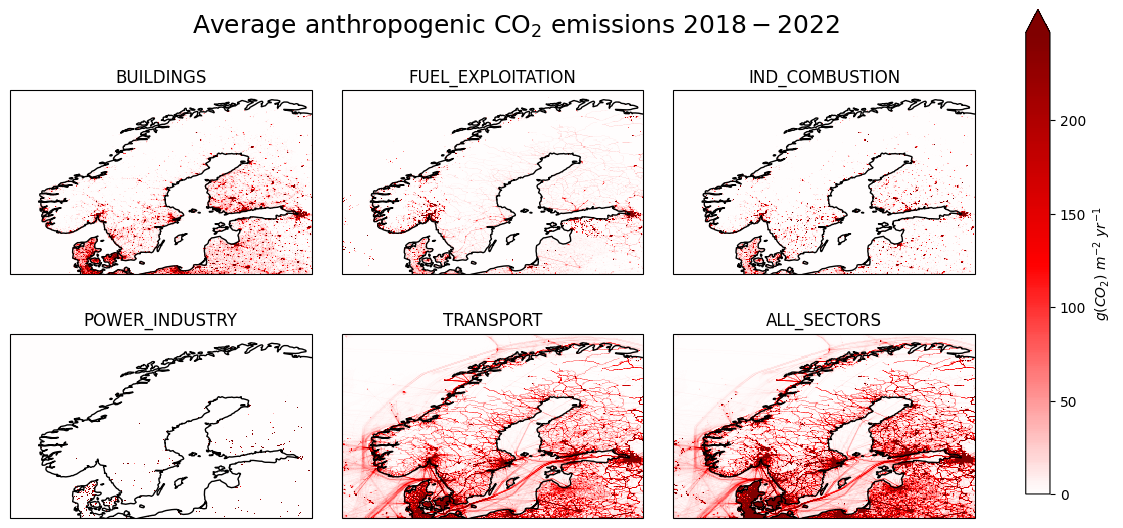

In [116]:

from truncate_colormap import truncate_colormap
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_anth"
ncols = 3
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="Average anthropogenic CO$_2$ emissions $2018-2022$"

plot_sector_averages(sector_means_subset, "emi_anth", ncols, cmap, cbar_label, suptitle=suptitle)
figpath = "/home/pietaril/Documents/plots/EDGAR8/"
figname = f"EDGAR8_scandinavia_sectorwise_mean_emis_2018_2022_v2.png"
plt.savefig(figpath+figname)
plt.draw()


In [114]:
from truncate_colormap import truncate_colormap
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_anth"
ncols = 4
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="Average anthropogenic CO$_2$ emissions $2018-2022$"


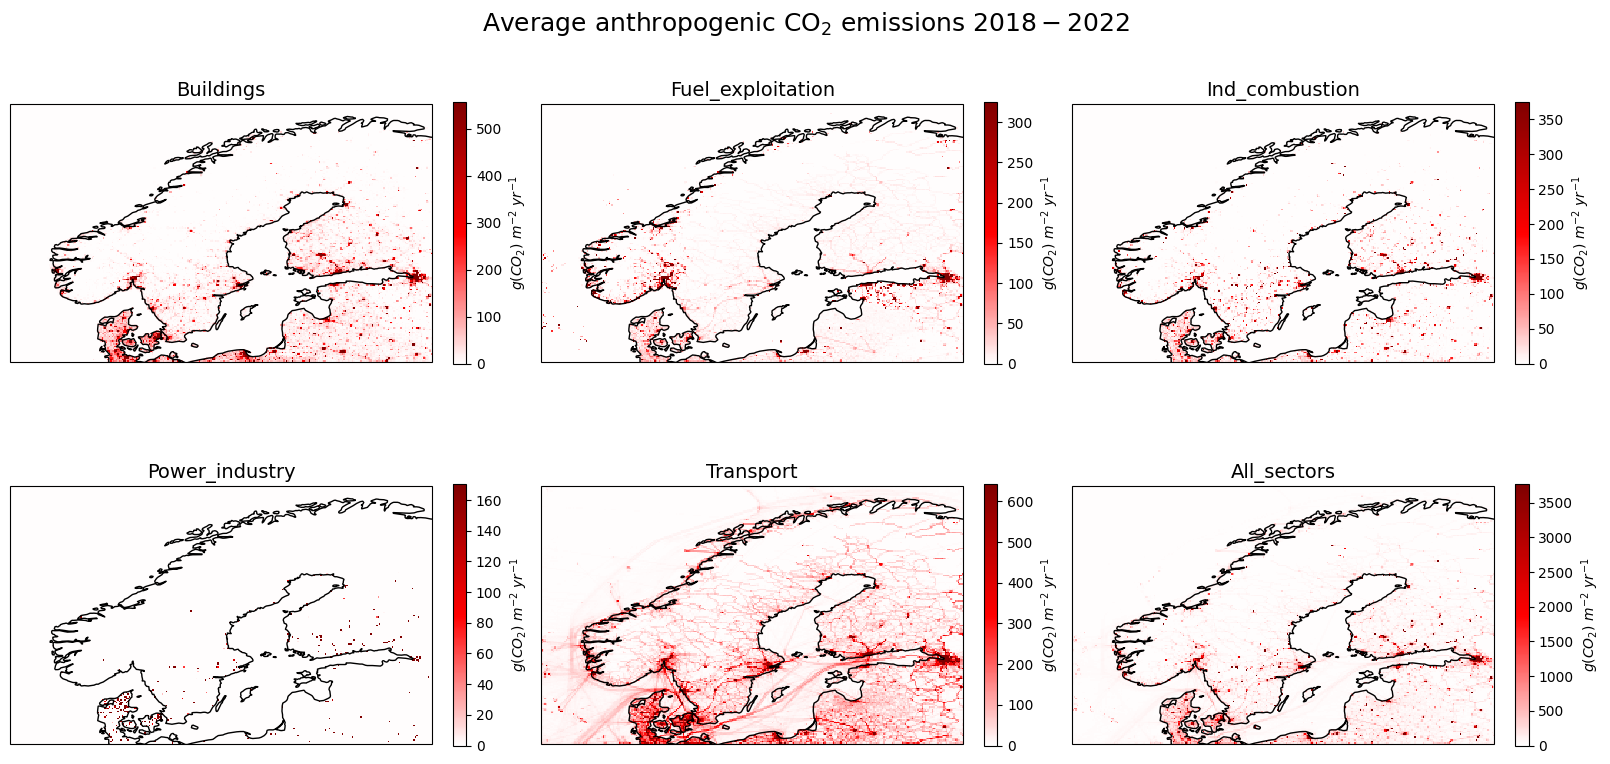

In [115]:

sectors = sector_means_subset.sector.values  # Get the sector names

# Create a figure with subplots
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    figsize=(16, 8), 
    subplot_kw={"projection": ccrs.PlateCarree()},  # Add PlateCarree projection
    constrained_layout=True
)

# Flatten axes to handle all subplots (if there are fewer sectors than subplots, the remaining axes will not be used)
axes = axes.flatten()


# Iterate over each sector and plot
for ax, sector in zip(axes, sectors):
    # Select data for the current sector and time slice
    da_sector = emi_anth.sel(sector=sector)
    
    # Ensure latitude and longitude are correctly set as x and y
    da_sector = da_sector.rename({"latitude": "lat", "longitude": "lon"})

    vmin, vmax = np.percentile(da_sector.values, [0.5, 99.5])

    # Plot the data using pcolormesh (matplotlib)
    mesh = ax.pcolormesh(
        da_sector.lon, da_sector.lat, da_sector.values,
        transform=ccrs.PlateCarree(),  # Transform data coordinates
        cmap=cmap, shading="auto", vmin=vmin, vmax=vmax
    )

    # Add coastlines and gridlines
    ax.coastlines()
    ax.set_title(f"{sector.capitalize()}", fontsize=14)
    #ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7)

    # Add colorbar
    cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.7)
    cbar.set_label(cbar_label, fontsize=10)
fig.suptitle(suptitle, fontsize=18)

# Show the plot
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/"
figname = f"EDGAR8_scandinavia_sectorwise_mean_emis_individ_cbars_2018_2022_v2.png"
plt.savefig(figpath+figname)
plt.draw()




# Compute and plot total emissions (Tg/year)

In [4]:


from areagrid import areagrid



def monthly_fluxes_to_Mt_per_year(fname):
    """Helper function to convert a dataset with a year of monthly EDGAR8 flux gridmaps (with all sectors summed together)
    from kg m-2 hr-1 to a single gridmap for the whole year with unit MtCO2/year.
    
    Input:
    fname (str): path to monthly data with unit kg m-2 hr-1
    Output:  an Xarray dataset containing a gridmap for the whole year with unit Mt/year."""

    ds = xr.open_dataset(fname)
    #ensure that the time axis in ascending order
    ds = ds.sortby("time")

    lat = ds["latitude"].values
    lon = ds["longitude"].values
    #pick the first time value to be the timestamp representing the whole year
    time = ds["time"].values[0]



    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    #the first dimension here is the month 
    fluxes = ds["emi_anth"]

    # pointwise multiplication by area
    totals = fluxes * grid_of_areas

    # compute  how many seconds per each of the months in the year in question
    year = ds["time"].dt.year.values[0]
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))

    #multiply the monthly gridmaps by hours per month
    totals = hours_per_month *totals

    # kg to megatons
    totals = totals.sum(dim="time") * 1e-9
   
    totals = totals.to_dataset()

    totals.coords["time"] = (time) 
    totals = totals.expand_dims("time")

    #rename fluxes to emissions
    variable_rename_map = {
    "emi_anth":"tot_emi_anth"
    }
    totals = totals.rename(variable_rename_map)
    totals.attrs.update({"description": "Total yearly anthropogenic emissions in Mt/year computed from EDGAR_2024_GHG CO2 monthly fluxes across all sectors",
                           "units": "Mt/year"})

    

    return totals



    
    

In [14]:
# compute and save to file the total emissions

fnames = [os.path.join(OUT_PATH,file) for file in os.listdir(OUT_PATH)]
TOTALS_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/gridded_total_emissions_calculated_from_fluxes/"
for f in fnames:
    tot = monthly_fluxes_to_Mt_per_year(f)
    year = extract_year(f)
    tot.to_netcdf(os.path.join(TOTALS_PATH, f"total_emis_from_fluxes_{year}.nc"))


In [32]:
TOTALS_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/gridded_total_emissions_calculated_from_fluxes/"

totfiles = [os.path.join(TOTALS_PATH,file) for file in os.listdir(TOTALS_PATH)]
datasets = [xr.open_dataset(f) for f in totfiles]


ds = xr.concat(datasets, dim="time") 
ds = ds.sortby("time")

eur_tot = ds["tot_emi_anth"]


Plot the total emissions

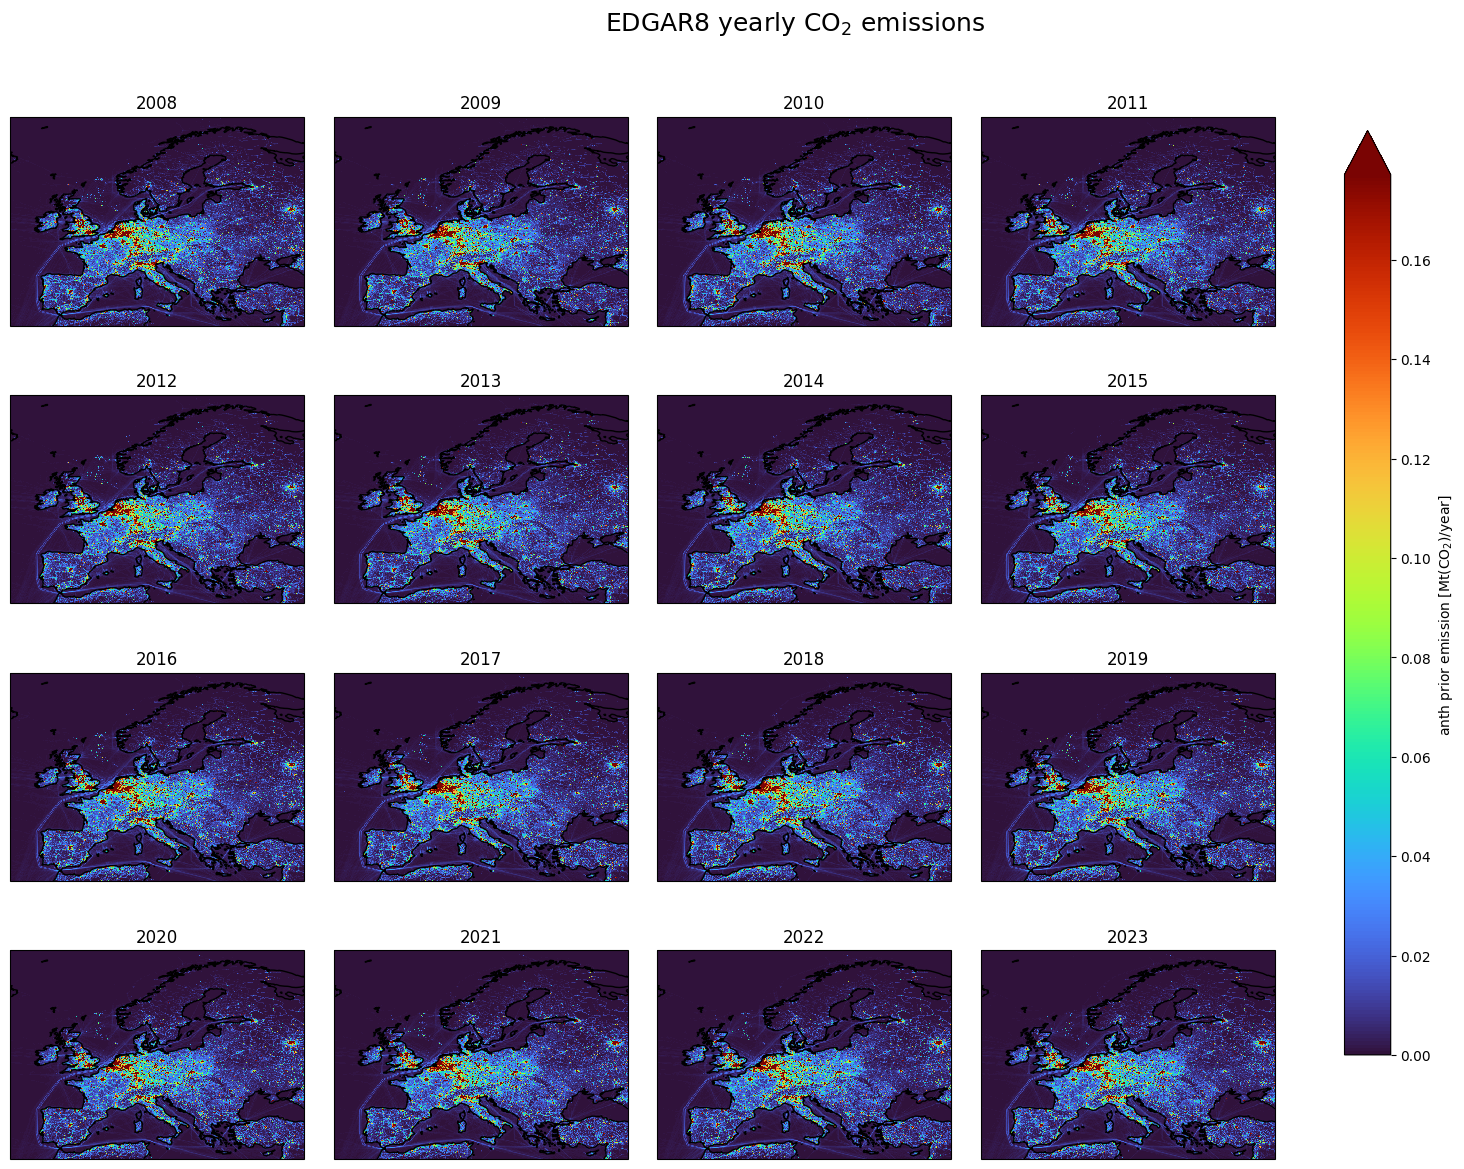

In [34]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

g = eur_tot.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.25, cmap = mpl.colormaps["turbo"],
                    subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "anth prior emission [Mt(CO$_2$)/year]", shrink=0.8 ),

)


for i, ax in enumerate(g.axes.flat):
    time = str(eur_tot.time.values[i])[0:4]
    ax.set_title(time)
    ax.coastlines()
    #ax.gridlines(draw_labels=False, linewidth=0.5, color='darkgray', alpha=0.5, linestyle='--')

g.fig.suptitle("EDGAR8 yearly CO$_2$ emissions", fontsize=18)
g.fig.subplots_adjust(top=0.9, right=0.8, wspace=0.1, hspace=0.2)

plt.draw()

figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_yearly_CO2_emissions_from_fluxes.png"
plt.savefig(figpath+figname)
plt.draw()

In [33]:
ds

<xarray.Dataset>
Dimensions:       (latitude: 390, longitude: 550, time: 16)
Coordinates:
  * latitude      (latitude) float64 34.05 34.15 34.25 ... 72.75 72.85 72.95
  * longitude     (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time          (time) datetime64[ns] 2008-01-15 2009-01-15 ... 2023-01-15
Data variables:
    tot_emi_anth  (time, latitude, longitude) float64 0.0006915 ... 2.296e-05
Attributes:
    description:  Total yearly anthropogenic emissions in Mt/year computed fr...
    units:        Mt/year

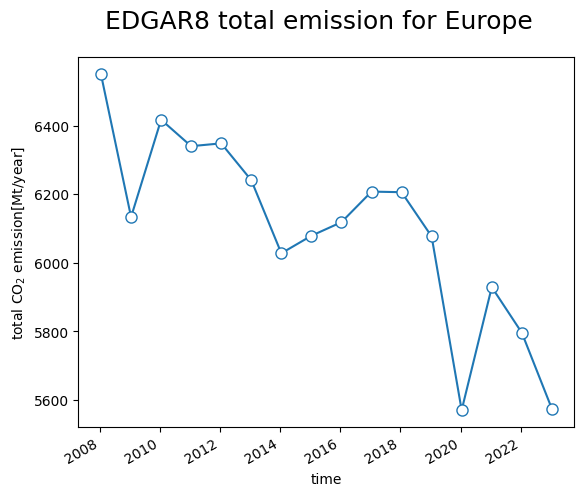

In [78]:
fig, ax = plt.subplots()
domain_tot = ds.sum(dim=("latitude", "longitude"))
domain_tot["tot_emi_anth"].plot(x="time", ax=ax, marker='.', linestyle='solid', markersize=16, markerfacecolor='white')
ax.set_ylabel("total CO$_2$ emission[Mt/year]")
fig.suptitle("EDGAR8 total emission for Europe", fontsize = 18 )
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_yearly_totals_CO2.png"
#plt.savefig(figpath+figname)


# Compute totals per sector

In [35]:

def g_per_m2_per_yr_to_Mt_per_yr(ds):
    
    lat = ds["latitude"].values
    lon = ds["longitude"].values


    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    # pointwise multiplication by area
    totals = ds["emi_anth"] * grid_of_areas


    domain_tot = totals.sum(dim=("latitude", "longitude"))

    #g to Mt
    domain_tot = domain_tot*1e-12

    return domain_tot

In [ ]:
DATA_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/g_per_m2_per_yr/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]

ds_domain_tot_by_sector = xr.Dataset()
input_files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]
inputs_by_sector = fnames_by_sector(input_files)
for (sector, f) in inputs_by_sector.items():
    #print(sector)
    assert len(f) == 1
    ds = xr.open_dataset(f[0])
    #scand = select_area(aoi_scand, ds)
    #scand = scand.isel(time=scand.time.dt.year.isin(years))
    total = g_per_m2_per_yr_to_Mt_per_yr(ds)
    ds_domain_tot_by_sector[sector] = total
    ds.close()

# add the totals to the dataset for plotting
ds_domain_tot_by_sector["ALL_SECTORS"] = domain_tot["tot_emi_anth"]
ds_domain_tot_by_sector

AGRICULTURE
BUILDINGS
FUEL_EXPLOITATION
IND_COMBUSTION
IND_PROCESSES
POWER_INDUSTRY
TRANSPORT
WASTE


Data variables:
    AGRICULTURE        (time) float64 45.94 45.31 42.7 ... 51.64 46.18 48.32
    BUILDINGS          (time) float64 1.154e+03 1.122e+03 ... 1.029e+03 993.8
    FUEL_EXPLOITATION  (time) float64 365.7 343.5 370.4 ... 362.1 356.8 348.5
    IND_COMBUSTION     (time) float64 852.3 739.0 803.7 ... 862.3 820.9 787.7
    IND_PROCESSES      (time) float64 399.1 345.1 372.4 ... 381.1 348.4 345.4
    POWER_INDUSTRY     (time) float64 2.177e+03 2.035e+03 ... 1.466e+03
    TRANSPORT          (time) float64 1.548e+03 1.495e+03 ... 1.576e+03
    WASTE              (time) float64 7.943 8.075 8.451 ... 9.258 9.396 9.55

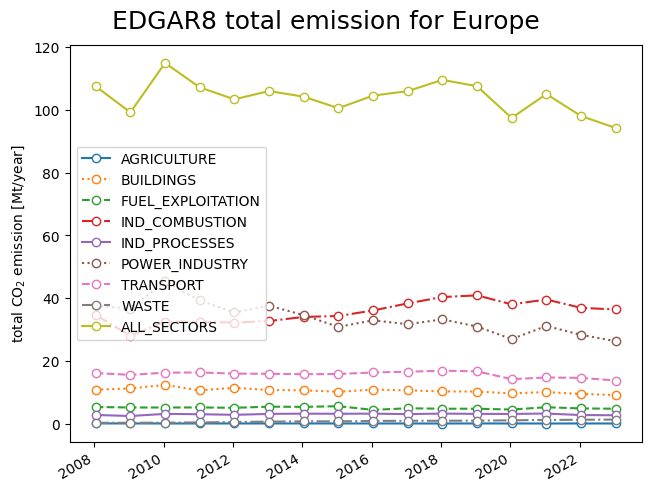

In [68]:
fig, ax = plt.subplots(layout="constrained")#, figsize=(9,6))

vars = list(ds_domain_tot_by_sector.data_vars.keys())
linestyles = ["solid", "dotted", "dashed", "dashdot"]
linestyles = linestyles*3

for (ind,var) in enumerate(vars):
    data = ds_domain_tot_by_sector[var]
    data.plot(x="time", ax=ax, marker='.', linestyle=linestyles[ind], markersize=12, markerfacecolor='white', label=var)


#Shrink current axis by 20%
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left')#, bbox_to_anchor=(0.5, 0.8))
ax.set_ylabel("total CO$_2$ emission [Mt/year]")
ax.set_xlabel("")
fig.suptitle("EDGAR8 total emission for Europe", fontsize = 18 )
#plt.legend()
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_yearly_totals_CO2.png"
#plt.savefig(figpath+figname)

# Domain totals for Finland

* I found out by plotting that Finland is Band1 = 83.

In [45]:

def get_fin_mask(data_to_be_masked):

    """Helper function to get Finland mask with the same dimensionality
    as the data to be masked (when the data has the aoi used in this function. Could
    later improve this to read the aoi also from the input data)"""

    MASK_PATH = "/home/pietaril/Documents/data/masks/country_masks/eez_01x01.nc4"
    ds_mask = xr.open_dataset(MASK_PATH)
    msk = ds_mask.Band1
    ds_mask.close()

    #limit the mask first to the same domain where the saved g/m2/yr values are
    aoi = [-15, 40, 34, 73]
    msk = select_area(aoi,msk)

    #Finland = 83
    msk_fin = msk==83

    #rename dimensions to match the ones in the data
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        }
    msk_fin = msk_fin.rename(rename_map)

    #expand time dimension to match the data
    msk_fin_expanded = msk_fin.expand_dims(time=data_to_be_masked.time)

    return msk_fin_expanded


In [55]:

#expand the mask to match the dimensions of the data
msk_fin_expanded = get_fin_mask(eur_tot)
fin_tot = eur_tot.where(msk_fin_expanded.values, drop=False)
fin_tot = fin_tot.sum(dim=("latitude", "longitude"))

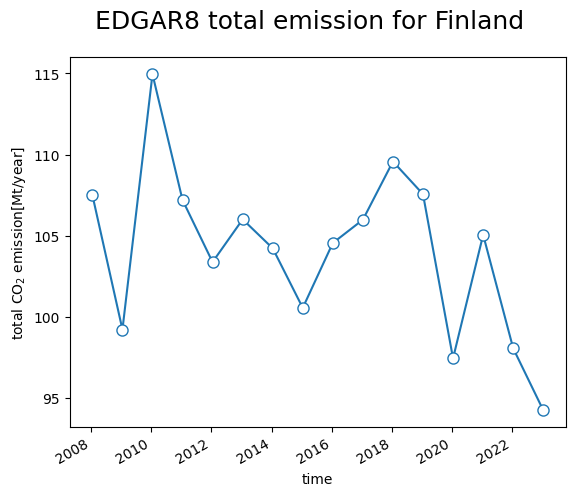

In [56]:


fig, ax = plt.subplots()

fin_tot.plot(x="time", ax=ax, marker='.', linestyle='solid', markersize=16, markerfacecolor='white')
ax.set_ylabel("total CO$_2$ emission[Mt/year]")
fig.suptitle("EDGAR8 total emission for Finland", fontsize = 18 )
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_yearly_totals_CO2.png"
#plt.savefig(figpath+figname)





In [57]:
DATA_PATH = "/home/pietaril/Documents/data/EDGAR8_CO2/domain_-15_40_34_73/fluxes_per_sector/g_per_m2_per_yr/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]
ds_domain_tot_by_sector = xr.Dataset()
input_files = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]
inputs_by_sector = fnames_by_sector(input_files)

first = True
for (sector, f) in inputs_by_sector.items():
    #print(sector)
    assert len(f) == 1
    ds = xr.open_dataset(f[0])

    if first:
        #shape the mask to match the dimensions of the first file
        msk_fin_expanded = get_fin_mask(ds)
        first = False
    fin = ds.where(msk_fin_expanded.values, drop=False)
    total = g_per_m2_per_yr_to_Mt_per_yr(fin)
    ds_domain_tot_by_sector[sector] = total
    ds.close()

# add the totals to the dataset for plotting
ds_domain_tot_by_sector["ALL_SECTORS"] = fin_tot
ds_domain_tot_by_sector

<xarray.Dataset>
Dimensions:            (time: 16)
Coordinates:
  * time               (time) datetime64[ns] 2008-01-15 ... 2023-01-15
Data variables:
    AGRICULTURE        (time) float64 0.05196 0.05157 ... 0.04294 0.03758
    BUILDINGS          (time) float64 10.83 11.2 12.34 ... 10.05 9.445 9.118
    FUEL_EXPLOITATION  (time) float64 5.295 5.138 5.129 ... 5.22 4.838 4.739
    IND_COMBUSTION     (time) float64 34.63 28.0 32.49 ... 39.56 36.9 36.39
    IND_PROCESSES      (time) float64 2.752 2.417 3.1 2.991 ... 3.21 2.725 2.663
    POWER_INDUSTRY     (time) float64 37.6 36.6 45.33 39.26 ... 31.12 28.3 26.27
    TRANSPORT          (time) float64 16.1 15.55 16.23 ... 14.7 14.58 13.74
    WASTE              (time) float64 0.2633 0.2551 0.307 ... 1.16 1.226 1.295
    ALL_SECTORS        (time) float64 107.5 99.21 115.0 ... 105.1 98.05 94.24

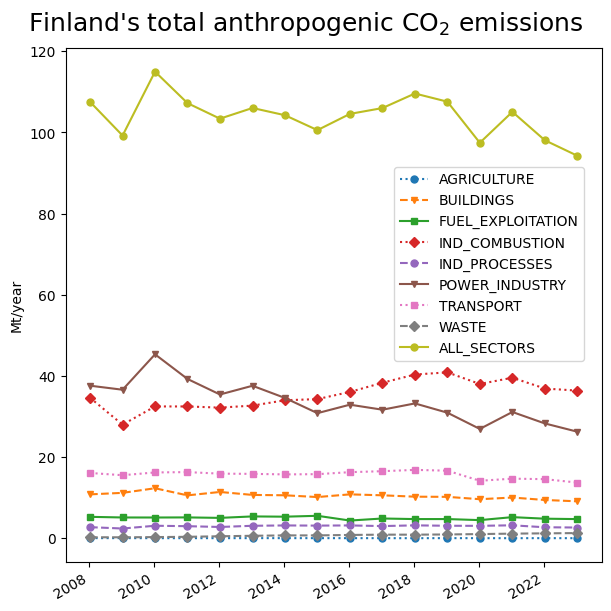

In [97]:
fig, ax = plt.subplots(layout="constrained", figsize=(6,6))#, figsize=(9,6))

vars = list(ds_domain_tot_by_sector.data_vars.keys())
linestyles = ["dotted", "dashed", "solid"]
linestyles = linestyles*3
markers = ['o', 'v', 's', 'D']
markers = markers*3

for (ind,var) in enumerate(vars):
    data = ds_domain_tot_by_sector[var]
    data.plot(x="time", ax=ax, marker= markers[ind], linestyle=linestyles[ind], markersize=5,  label=var) #markerfacecolor='white',


#Shrink current axis by 20%
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(0.6, 0.58), fontsize=10)
ax.set_ylabel("Mt/year")
ax.set_xlabel("")
fig.suptitle("Finland's total anthropogenic CO$_2$ emissions", fontsize = 18 )
#plt.legend()
#plt.yscale('log')
plt.draw()
figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"EDGAR8_Fin_yearly_totals_CO2.png"
plt.savefig(figpath+figname)

# Sanity check that both ways of computing the totals give the same result
* by both ways I mean by my original method of computing the totals from the flux_sum gridmaps with unit kg/m2/hr versus like I computed the sector totals from the gridmaps with the unit Tuula requested for plots, i.e. g/m2/yr 

In [81]:

sectors_sum = ds_domain_tot_by_sector.to_array().sum("variable")

np.allclose(domain_tot["tot_emi_anth"].values, sectors_sum)

array([6550.32367625, 6133.61347276, 6417.51025491, 6340.30221455,
       6348.53128121, 6240.92944815, 6027.96617144, 6079.04444342,
       6118.58534606, 6207.84181221, 6206.06592997, 6077.07584401,
       5570.33059453, 5929.19645022, 5796.23700122, 5574.60040975])

# Old stuff

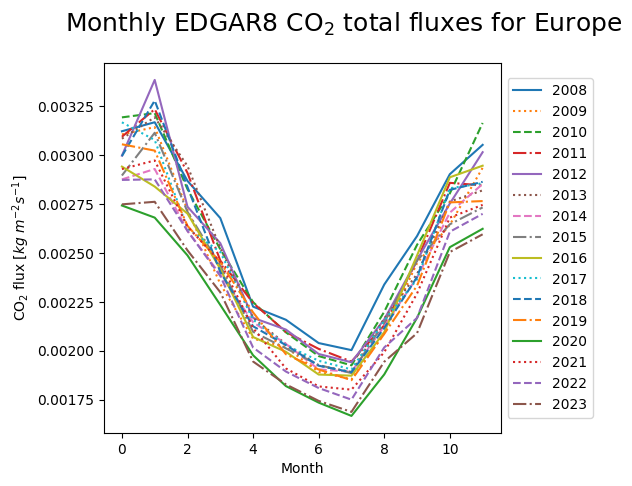

<Figure size 640x480 with 0 Axes>

In [30]:
#pretty plot but the unit doesn't make sense
import matplotlib

linestyles = ["solid", "dotted", "dashed", "dashdot"]
linestyles = linestyles*4

#cmap = matplotlib.colormaps['viridis'].resampled(16).colors
fig, ax = plt.subplots(layout="constrained")
for ind, year in enumerate(monthly_totals.columns):
    ax.plot(monthly_totals[year], label=year, linestyle=linestyles[ind] ) #color=cmap[ind])
ax.set_xlabel("Month")
ax.set_ylabel("CO$_2$ flux [$kg$ $m^{-2} s^{-1}$]")
#Shrink current axis by 20%
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle(f"Monthly EDGAR8 CO$_2$ total fluxes for Europe", fontsize=18)
plt.show()
plt.savefig("/home/pietaril/Documents/plots/EDGAR8/monthly_totals.png")


